# Lección 2 (parte 2) - La función de autocorrelación parcial

En esta segunda parte de la lección veremos qué es la función de autocorrelación parcial (o PACF por sus siglas en Inglés: *Partial Autocorrelation Function*), que resulta **clave para determinar el orden (p) de los modelos AR**.

## 1. Breve repaso: la función de autocorrelación (ACF)


<div class="alert alert-block alert-success"> La función de autocorrelación resulta de comparar la serie de tiempo consigo misma para diferentes desplazamientos, también conocidos como «lags».</div>

### 1.1. Limitaciones

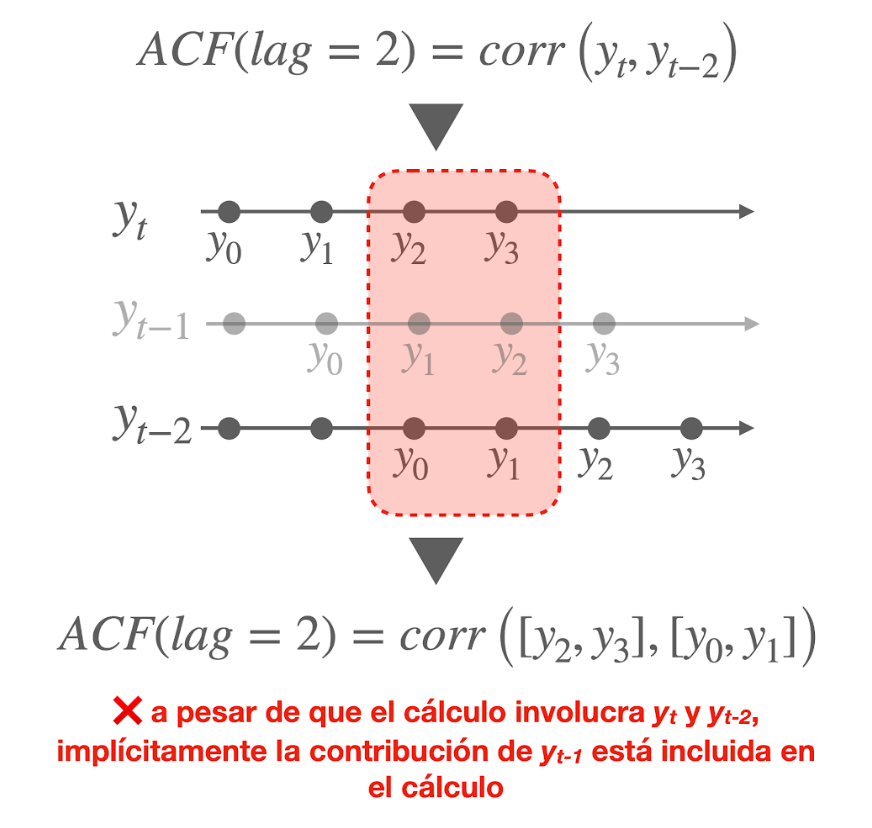

<div class="alert alert-block alert-danger"> En cada lag la autocorrelación incluye contribuciones directas e indirectas</div>

## 2. La función de autocorrelación parcial (PACF)

<div class="alert alert-block alert-success"> La función de autocorrelación parcial calcula para cada lag sólo las correspondientes contribuciones directas </div>

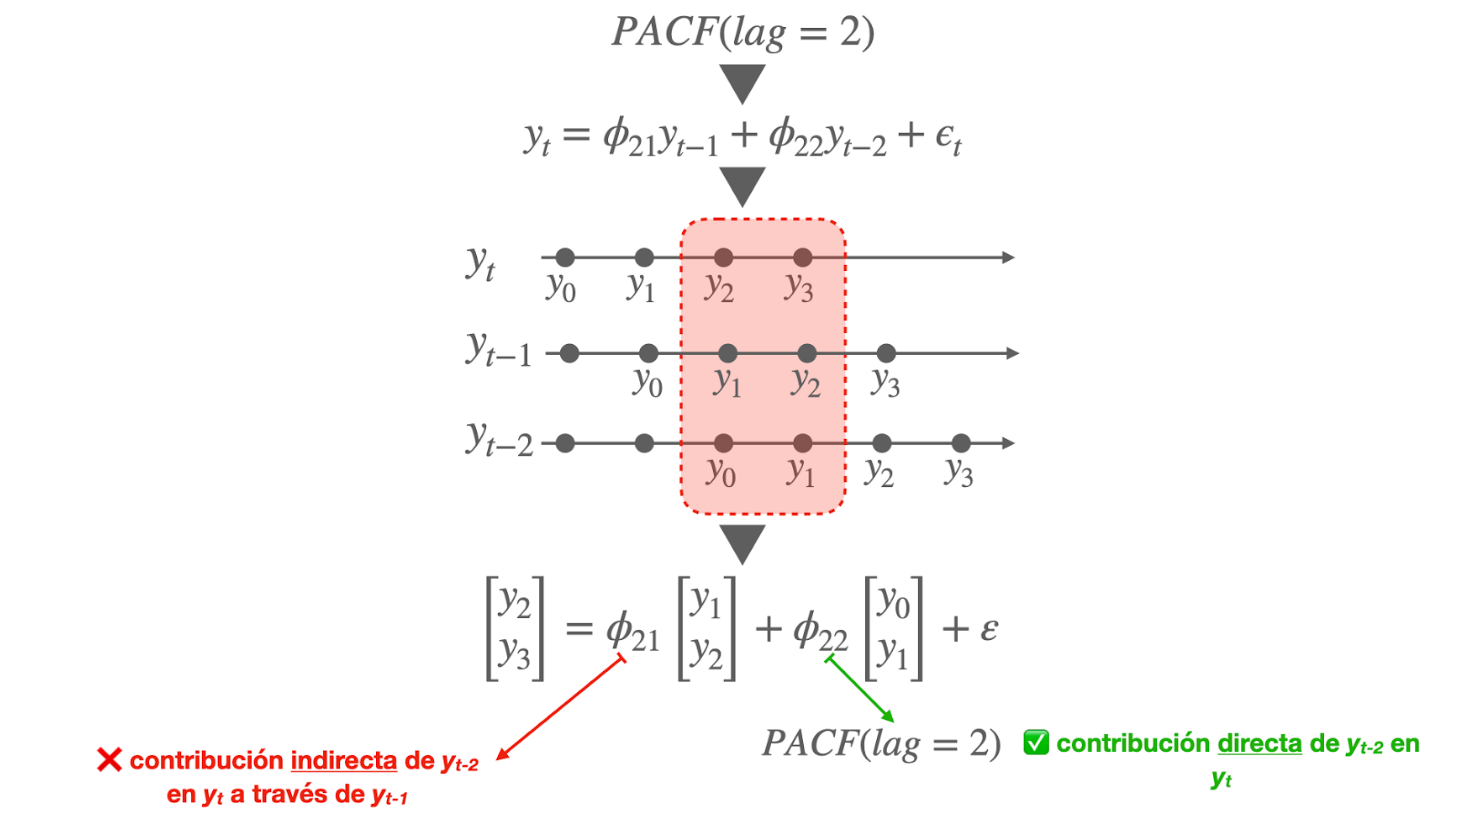
### 2.1. Ventaja (útil en los modelos AR)

<div class="alert alert-block alert-success">!La función de autocorrelación parcial nos permite encontrar el orden "p" de un modelo AR!</div>

Ejemplo:

- Si calculamos la PACF para 10 lags (1, 2, 3, ..., 10) y vemos que sólo los 4 primeros valores son diferentes de cero y los valores restantes son cero, **entonces p=4**

## 3. Ejemplo práctico: PACF y modelos AR

En este ejemplo construiremos un modelo predictivo AR y usaremos precisamente la PACF para determinar su orden.

Comencemos cargando las librerías requeridas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Funciones ACF y PACF

# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA
import statsmodels.api as sm

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

### 3.1. Lectura y exploración de la Serie de Tiempo

In [4]:
df = pd.read_csv('datos/serie_estacionaria_AR.csv')
df

,unique_id,ds,y
0,estacionaria,1,22.850111
1,estacionaria,2,21.791273
2,estacionaria,3,19.514480
3,estacionaria,4,19.195381
4,estacionaria,5,21.196449
...,...,...,...
195,estacionaria,196,22.497315
196,estacionaria,197,22.967683
197,estacionaria,198,22.539644
198,estacionaria,199,21.382654


Se trata de una Serie donde las marcas (columna "ds") son simplemente los segundos transcurridos.

Veamos el comportamiento en el tiempo de esta Serie y dibujemos además su valor medio:

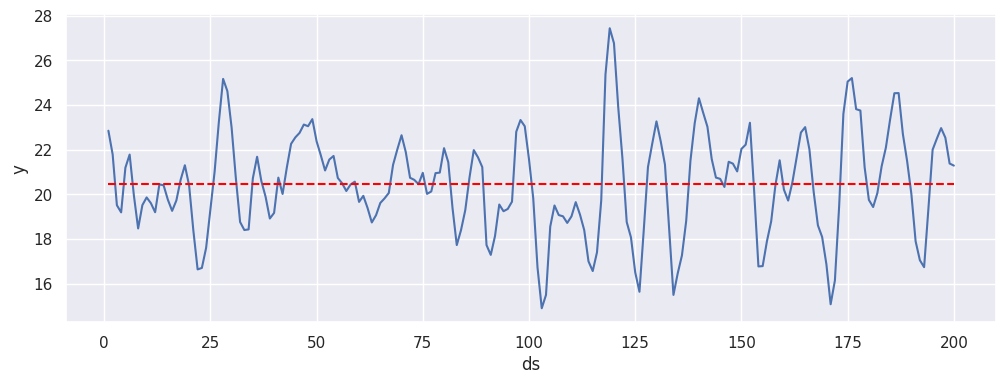

In [5]:
sns.lineplot(df, x="ds", y="y")
plt.hlines(df["y"].mean(), xmin=df["ds"].min(), xmax=df["ds"].max(), color='red', linestyle='--')

Aunque podríamos hacer una prueba de estacionariedad, gráficamente podemos ver algunas características que hacen que la serie sea estacionaria:

1. Su media se mantiene constante a lo largo de y =~ 20
2. Y al parecer su desviación (qué tanto se aleja cada observación del valor medio) es relativamente constante

Obviaremos la prueba de estacionariedad y asumiremos que esta serie puede ser modelada usando precisamente un modelo AR.

### 3.2. ACF y PACF de la Serie

Veamos qué características tienen la ACF y PACF de esta serie estacionaria:

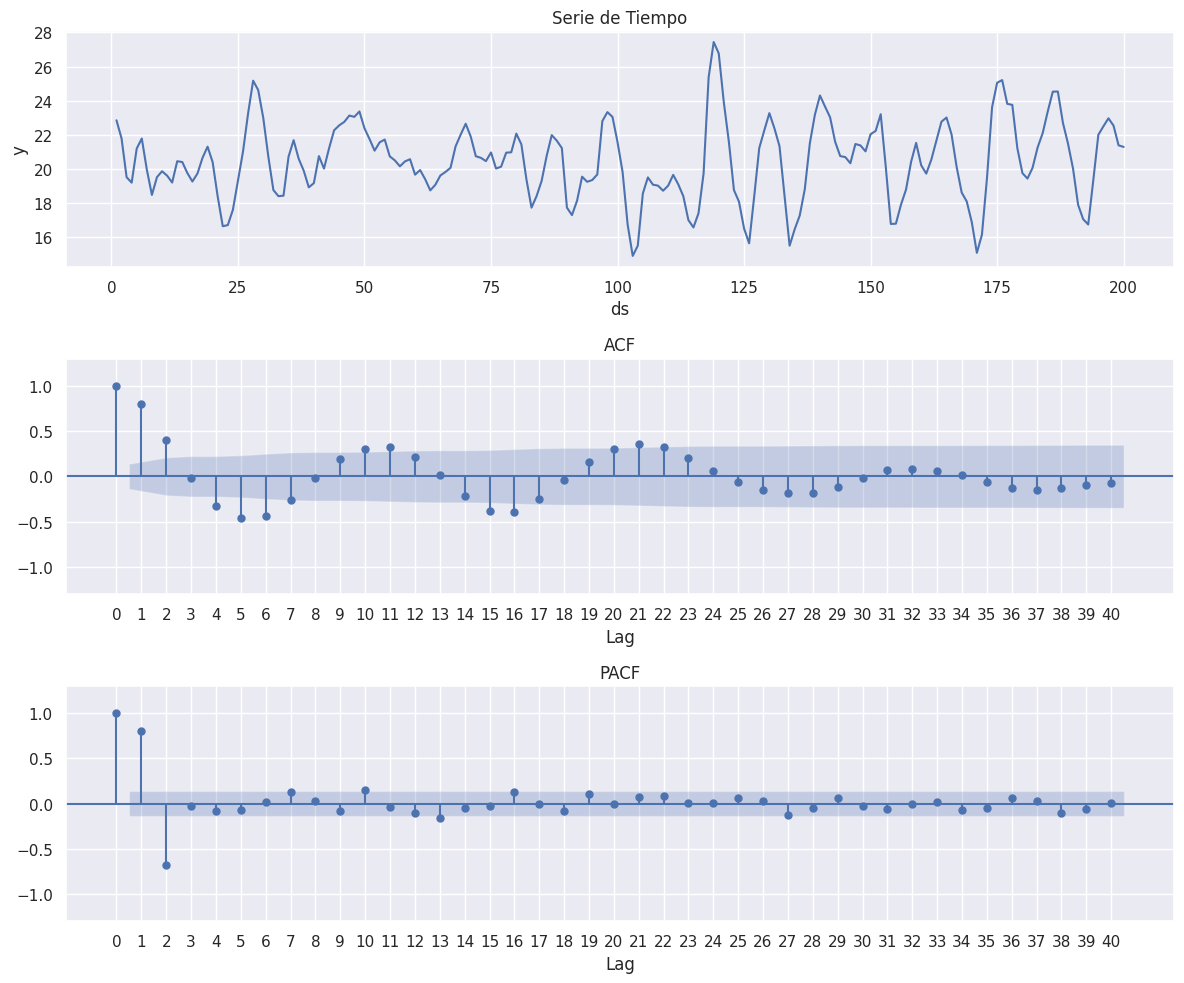

In [6]:
# Grilla de 3x1
fig, axs = plt.subplots(3,1, figsize=(12,10))

# Serie de tiempo
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie de Tiempo')

# ACF
LAGS = 40
plot_acf(df["y"], 
        adjusted=True,
        alpha=0.05, # Intervalo de confianza del 95%
        lags = LAGS, 
        ax = axs[1]);
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_ylim([-1.3, 1.3])
axs[1].grid(True)

# PACF
plot_pacf(df["y"],
        alpha=0.05, # Intervalo de confianza del 95%
        lags=LAGS,
        ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
axs[2].set_ylim([-1.3, 1.3])
axs[2].grid(True)

fig.tight_layout()

**Observaciones:**
- La ACF decae a cero gradualmente. Esto es típico de una serie estacionaria, pues entre más lags haya entre la serie y sí misma, menor será la correlación
- La PACF tiene los primeros valores diferentes de cero (estadísticamente hablando, por fuera de la región azul) y luego **se hace estadísticamente cero de manera abrupta**
    - Esto es precisamente lo que esperamos observar en la PACF en este caso
    - Y quiere decir que el último coeficiente PACF diferente de cero será el orden a usar en el modelo AR: p=2
- Otra observación en la PACF:
    - El coeficiente en el lag = 1 es positivo
    - Mientras que el coeficiente en el lag = 2 es negativo
    - Esto quiere decir que cuando construyamos el modelo AR veremos que $\phi_1$ será positivo y $\phi_2$ será negativo

### 3.3. Entrenamiento del modelo ARIMA

Veamos cómo entrenar el modelo usando tanto StatsForecast como la librería statsmodels.

En ambos casos construiremos un modelo AR(p=2). Veamos primero el modelo en StatsForecast:

In [7]:
# Instancia del modelo
models = [ARIMA(order=(2, 0, 0), alias="AR(2)")] # p=2, d=0 (no hay componente I), q=0 (no hay componente MA)
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Entrenar con fit
sf.fit(df)

StatsForecast(models=[AR(2)])

Una vez entrenado el modelo podemos extraer toda su información accediendo al atributo "fitted_":

In [8]:
modelo_sf = sf.fitted_[0][0].model_
modelo_sf

{'coef': {'ar1': np.float64(1.3547448477462263),
  'ar2': np.float64(-0.6899720708069744),
  'intercept': np.float64(20.475491589547055)},
 'sigma2': np.float64(0.9524078687698107),
 'var_coef': array([[ 0.00031069, -0.0005969 ,  0.00085446],
        [-0.0005969 ,  0.00115406, -0.00165603],
        [ 0.00085446, -0.00165603,  0.00443332]]),
 'mask': array([ True,  True,  True]),
 'loglik': np.float64(-278.56101489949106),
 'aic': np.float64(565.1220297989821),
 'arma': (2, 0, 0, 0, 1, 0, 0),
 'residuals': array([ 1.02753776, -0.42547272, -1.10513856,  0.92966792,  1.79210886,
        -0.55287345, -1.79741764, -0.38780395,  1.39244049, -0.69747582,
        -0.69834612, -0.51993059,  1.10168913, -0.91479688, -0.63801525,
        -0.29109347,  0.40297793,  0.34972133,  0.07666177, -1.08214024,
        -1.41939024, -1.04322768, -0.02384707, -0.40987413,  0.11983564,
         0.14345077,  1.22978201,  1.3178636 , -0.30152735,  0.13571219,
        -0.29660181, -0.31509191,  0.42193222, -0.41

La interfaz de StatsForecast no es muy amigable, así que debemos escribir el código para acceder a la información que nos interesa:

In [9]:
# Extraer los parámetros del modelo entrenado (c, phi_1 y phi_2)
params = modelo_sf['coef']

# Imprimir
for name, value in params.items():
    print(f"Parametro {name:10} : {value:.4f}")


Parametro ar1        : 1.3547
Parametro ar2        : -0.6900
Parametro intercept  : 20.4755


Y podemos observar que el $\phi_1$ es positivo mientras que $\phi_2$ es negativo, lo cual coincide perfectamente con lo observado en la PACF de la Serie.

Así que este modelo $AR(2)$ es de la forma:

$$y_t = 20.4755 + 1.3547y_{t-1} -0.69y_{t-2}+\epsilon_t$$

Veamos cómo hacer lo mismo pero con "statsmodels":

In [10]:
# orden: (p, d, q)
modelo_sm = sm.tsa.ARIMA(df['y'], order=(2, 0, 0))
resultados = modelo_sm.fit()

# Con statsmodels es muy sencillo acceder a la información del modelo
print(resultados.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -278.561
Date:                Sat, 02 May 2026   AIC                            565.122
Time:                        19:57:25   BIC                            578.315
Sample:                             0   HQIC                           570.461
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.4755      0.207     98.795      0.000      20.069      20.882
ar.L1          1.3547      0.052     25.809      0.000       1.252       1.458
ar.L2         -0.6900      0.050    -13.815      0.0

Y con cualquiera de los dos modelos podemos hacer un análisis de residuales.

Recordemos que si el modelo es:

$$y_t = 20.4755 + 1.3547y_{t-1} -0.69y_{t-2}+\epsilon_t$$

los residuales serán el componente que no logra capturar el modelo, es decir:

$$residuales = \epsilon_t$$

Idealmente estos residuales deberían ser "pequeños" (comparados con los niveles originales de la Serie) y deberían tener una media cercana a cero, así como una ACF que no exhiba ningún patrón específico:

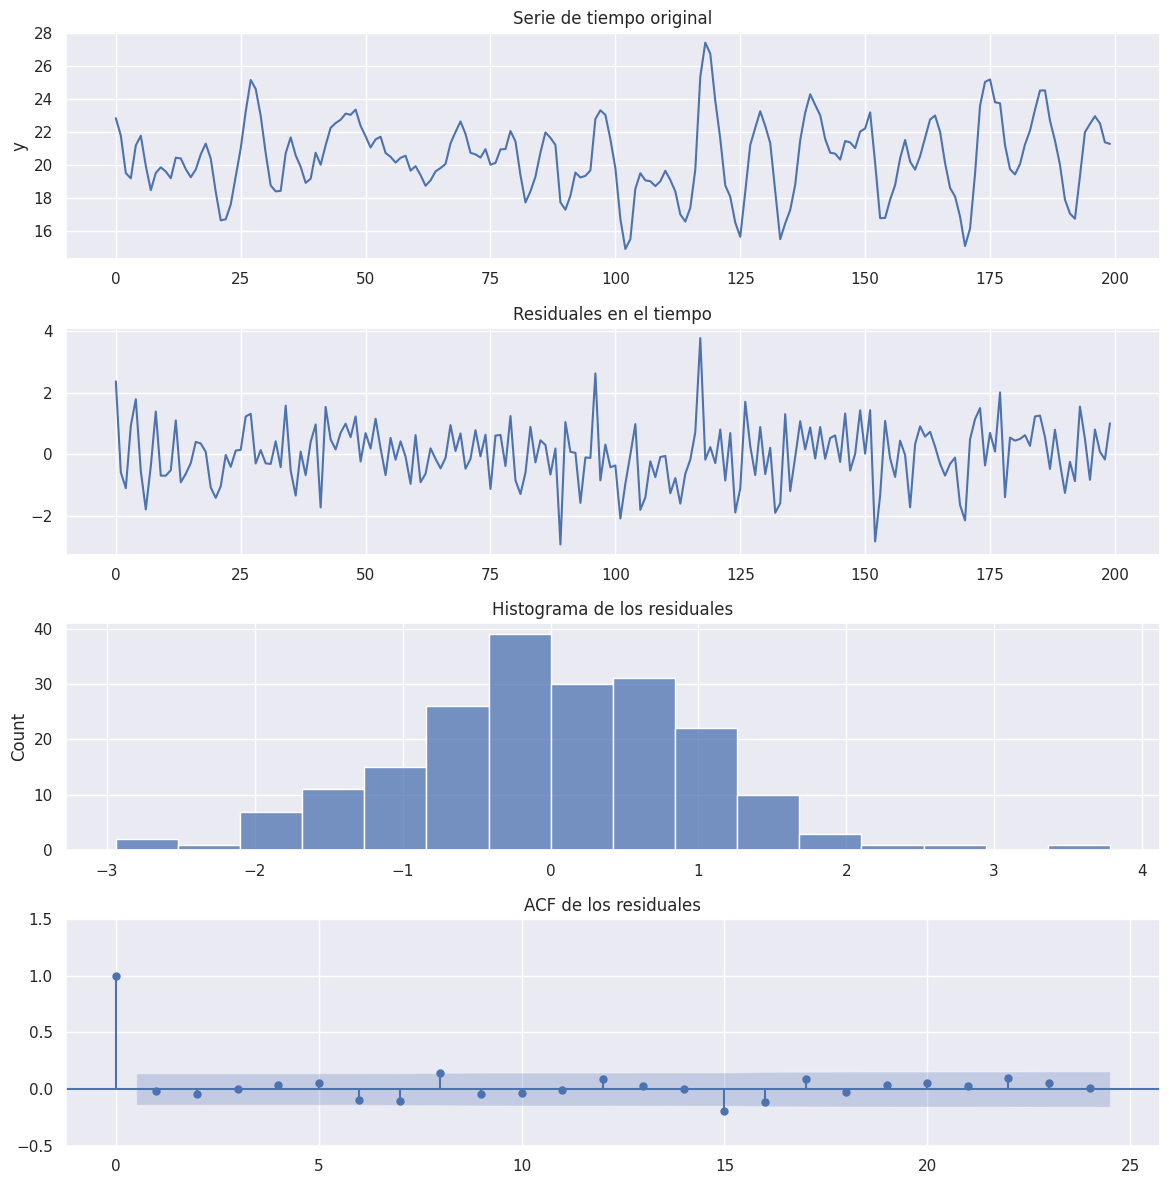

In [11]:
# Extraer residuales (de cualquiera de los dos modelos)
#res = modelo_sf['residuals']
res = resultados.resid.values

# Graficar serie, residuales en el tiempo, histograma y ACF de dichos residuales
fig, axs = plt.subplots(4,1,figsize=(12,12))

sns.lineplot(df["y"], ax=axs[0])
axs[0].set_title('Serie de tiempo original')

sns.lineplot(res, ax=axs[1])
axs[1].set_title('Residuales en el tiempo')

sns.histplot(res, ax=axs[2])
axs[2].set_title('Histograma de los residuales')

plot_acf(res, ax=axs[3])
axs[3].set_title('ACF de los residuales')
axs[3].set_ylim([-0.5, 1.5])

plt.tight_layout();

**Observaciones:**
- Vemos que los residuales son casi ideales: media cercana a cero, no exhiben patrones en la ACF
- Pero hay un ligero sesgo en el histograma hacia una media inferior a cero. Esto quiere decir que si $residuales = y_t - \hat{y_t}$, entonces en promedio el modelo AR(2) tiende a sobre-estimar ligeramente los valores en la Serie
- Además, vemos que algunos picos de los residuales se dan en t=90 y 120 aproximadamente, pues el modelo no logra capturas esas variaciones abruptas en la serie

## 4. Generación de pronósticos con el modelo AR

Podemos usar StatsForecast y la misma lógica que vimos en el curso de Suavizado Exponencial, para así generar pronósticos.

Supongamos que generaremos un pronóstico a 10 horas y dibujaremos la serie original, el pronóstico puntual y el intervalo de predicción del 90%:

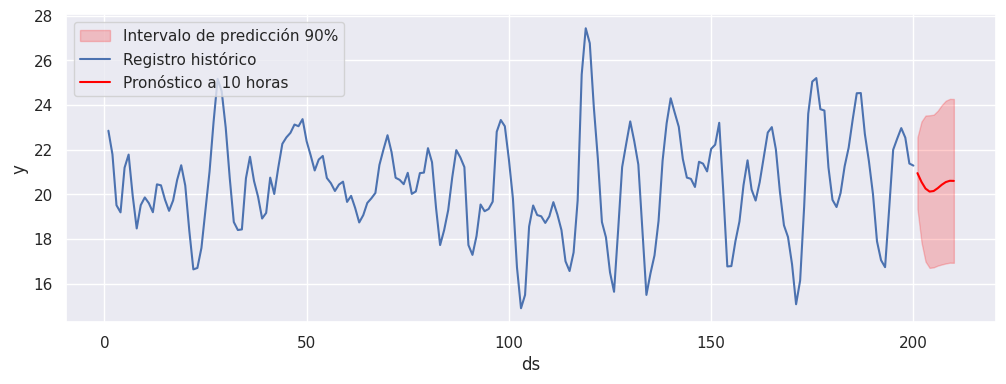

In [12]:
# Instancia modelo AR(2)
models = [ARIMA(order=(2, 0, 0), alias="AR(2)")] # p=2, d=0 (no hay componente I), q=0 (no hay componente MA)
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Pronóstico a h=10 horas
fc = sf.forecast(df=df,
                h=10,
                level=[90]
)

# Gráfico serie original, pronóstico e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc["ds"],
                y1 = fc['AR(2)-lo-90'],
                y2 = fc['AR(2)-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90%');
sns.lineplot(df, x="ds", y="y", label='Registro histórico');
sns.lineplot(fc, x="ds", y="AR(2)", color='red', label='Pronóstico a 10 horas');